<a href="https://colab.research.google.com/github/MuhammadAhmedButt25i3010/SEC_25i3010_25i3111_KraftKit/blob/main/Prjoject_25i3010.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [80]:
import numpy as np
data = np.load('mnist.npz')
print(data.files)
X_train = data["training_images"].reshape(-1, 784) / 255.0
Y_train = np.argmax(data["training_labels"], axis=1).flatten().astype(int)
X_test = data["test_images"].reshape(-1, 784) / 255.0
Y_test = np.argmax(data["test_labels"], axis=1).flatten().astype(int)
np.random.seed(42)
W1 = np.random.uniform(-0.5, 0.5, (784, 128))
b1 = np.zeros((1, 128))
W2 = np.random.uniform(-0.5, 0.5, (128, 64))
b2 = np.zeros((1, 64))
W3 = np.random.uniform(-0.5, 0.5, (64, 10))
b3 = np.zeros((1, 10))
Y_train_oh = np.eye(10)[Y_train]
Y_test_oh = np.eye(10)[Y_test]

KeyError: 'x_train is not a file in the archive'

In [ ]:
#Cell#2
def sigmoid(z):
  n=np.clip(z,-500,500)
  n=1/(1+np.exp(-n))
  return n
# Hint: use np.clip(z, -500, 500) to avoid overflow
def sigmoid_derivative(a):
  return a*(1-a)
# Hint: you derived this in Task 3 - express it in terms of a

In [81]:
#Cell#3
def forward_pass(X, W1, b1, W2, b2, W3, b3):
  # Layer 1
  Z1 = X @ W1 + b1
  # (weighted sum: X @ W1 + b1)
  A1 = sigmoid(Z1)
  #  (sigmoid activation)
  # Layer 2
  Z2 = A1 @ W2 + b2
  A2 = sigmoid(Z2)
  # Output layer
  Z3 = A2 @ W3 + b3
  A3 = sigmoid(Z3)
  return Z1, A1, Z2, A2, Z3, A3

In [82]:
#Cell#4
def mse_loss(Y_true, Y_pred):
  a= (Y_true-Y_pred)**2
  return a.mean()
# Y_true: one-hot matrix (m, 10)
# Y_pred: network output (m, 10)
# Return: a single scalar value

In [83]:
#Cell#5
def backpropagation(X, Y_true, Z1, A1, Z2, A2, Z3, A3, W1, W2, W3):
  m = X.shape[0]
  # Output layer delta
  delta3 = (-2*(Y_true - A3) * sigmoid_derivative(A3))
  # YOUR CODE (-2*(Y_true - A3) * sigmoid_derivative(A3))
  # Gradients for W3, b3
  dW3 = A2.T @ delta3/m
  db3 = np.sum(delta3, axis=0)/m
  # Hidden layer 2 delta
  delta2 = (delta3 @ W3.T * sigmoid_derivative(A2))
  # YOUR CODE (delta3 @ W3.T * sigmoid_derivative(A2))
  # Gradients for W2, b2
  dW2 = A1.T @ delta2/m
  db2 = np.sum(delta2, axis=0)/m
  # Hidden layer 1 delta
  delta1 =  (delta2 @ W2.T * sigmoid_derivative(A1))
  # YOUR CODE (delta2 @ W2.T * sigmoid_derivative(A1))
  # Gradients for W1, b1
  dW1 =X.T @ delta1 / m
  db1 = np.sum(delta1, axis=0)/m
  return dW1, db1, dW2, db2, dW3, db3

In [84]:
#Cell#6
def update_weights(W1, b1, W2, b2, W3, b3, dW1, db1, dW2, db2, dW3, db3, learning_rate):
  W1 = W1 - learning_rate * dW1
  W2 = W2 - learning_rate * dW2
  W3 = W3 - learning_rate * dW3
  b1 = b1 - learning_rate * db1
  b2 = b2 - learning_rate * db2
  b3 = b3 - learning_rate * db3
  return W1, b1, W2, b2, W3, b3
# Apply: W = W - learning_rate * dW
# b = b - learning_rate * db
# Return all updated weights and biases

In [85]:
#Cell#7
learning_rate = 0.1
epochs = 20
batch_size = 32
loss_history = []
for epoch in range(epochs):
# Shuffle training data
  idx = np.random.permutation(X_train.shape[0])
  X_shuf = X_train[idx]
  Y_shuf = Y_train_oh[idx] # one-hot labels
# Mini-batch loop
  for start in range(0, X_train.shape[0], batch_size):
    X_batch = X_shuf[start : start + batch_size]
    Y_batch = Y_shuf[start : start + batch_size]
    # Step 1: Forward pass
    Z1,A1,Z2,A2,Z3,A3 = forward_pass(X_batch, W1,b1,W2,b2,W3,b3)
    # Step 2: Compute loss
    loss = mse_loss(Y_batch, A3)
    # Step 3: Backpropagation
    dW1,db1,dW2,db2,dW3,db3 = backpropagation(
        X_batch, Y_batch, Z1,A1,Z2,A2,Z3,A3, W1,W2,W3)
    # Step 4: Update weights
    W1,b1,W2,b2,W3,b3 = update_weights(
        W1,b1,W2,b2,W3,b3,
        dW1,db1,dW2,db2,dW3,db3, learning_rate)
  # Record epoch loss
  _,_,_,_,_,A3_full = forward_pass(X_train,W1,b1,W2,b2,W3,b3)
  epoch_loss = mse_loss(Y_train_oh, A3_full)
  loss_history.append(epoch_loss)
  print(f"Epoch {epoch+1}/{epochs} Loss: {epoch_loss:.4f}")

Epoch 1/20 Loss: 0.0899
Epoch 2/20 Loss: 0.0900
Epoch 3/20 Loss: 0.0899
Epoch 4/20 Loss: 0.0899
Epoch 5/20 Loss: 0.0900
Epoch 6/20 Loss: 0.0899
Epoch 7/20 Loss: 0.0899
Epoch 8/20 Loss: 0.0899
Epoch 9/20 Loss: 0.0900
Epoch 10/20 Loss: 0.0899
Epoch 11/20 Loss: 0.0899
Epoch 12/20 Loss: 0.0898
Epoch 13/20 Loss: 0.0898
Epoch 14/20 Loss: 0.0898
Epoch 15/20 Loss: 0.0899
Epoch 16/20 Loss: 0.0899
Epoch 17/20 Loss: 0.0899
Epoch 18/20 Loss: 0.0898
Epoch 19/20 Loss: 0.0899
Epoch 20/20 Loss: 0.0898


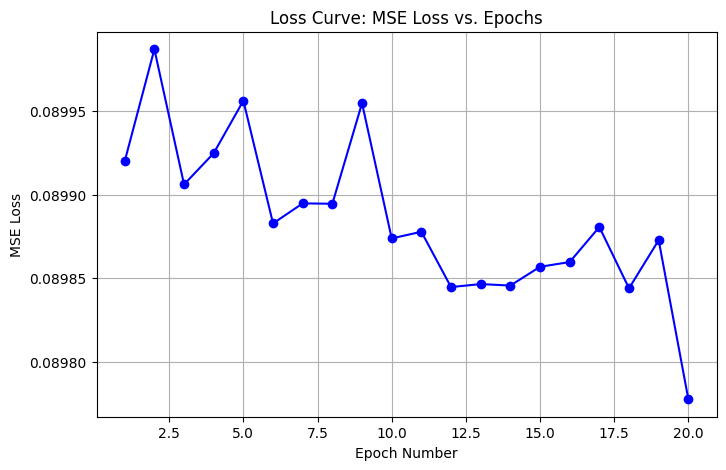

Final Classification Accuracy: 13.32%


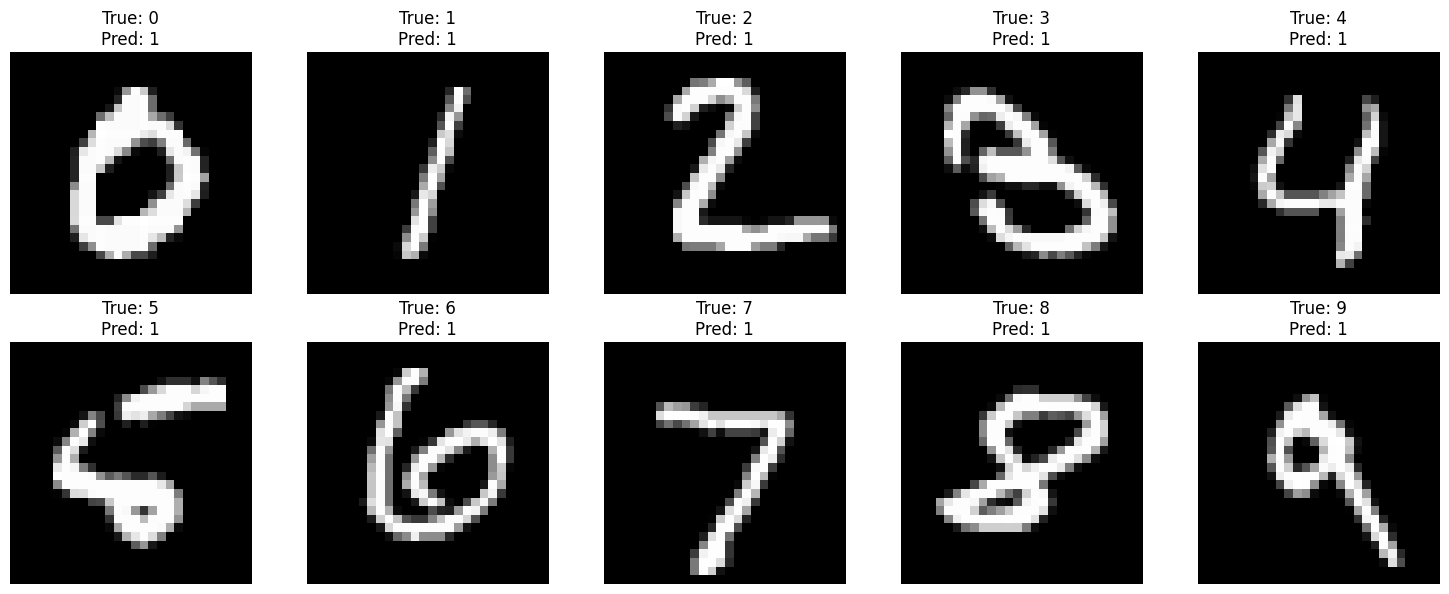

In [86]:
#Cell#8
import matplotlib.pyplot as plt

# 1. Loss Curve
plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs + 1), loss_history, marker='o', color='b', linestyle='-')
plt.title('Loss Curve: MSE Loss vs. Epochs')
plt.xlabel('Epoch Number')
plt.ylabel('MSE Loss')
plt.grid(True)
plt.show()

# 2. Test Accuracy
_, _, _, _, _, A3_test = forward_pass(X_test, W1, b1, W2, b2, W3, b3)
predictions = np.argmax(A3_test, axis=1)
accuracy = np.mean(predictions == Y_test) * 100
print(f"Final Classification Accuracy: {accuracy:.2f}%")

# 3. Sample Predictions (One per digit class)
plt.figure(figsize=(15, 6))
for i in range(10):
    # Find the first index in the test set that matches the digit i
    idx = np.where(Y_test == i)[0][0]
    img = X_test[idx].reshape(28, 28)

    # Get prediction for this specific image
    _, _, _, _, _, a3_single = forward_pass(X_test[idx:idx+1], W1, b1, W2, b2, W3, b3)
    pred_label = np.argmax(a3_single)

    plt.subplot(2, 5, i + 1)
    plt.imshow(img, cmap='gray')
    plt.title(f"True: {i}\nPred: {pred_label}")
    plt.axis('off')

plt.tight_layout()
plt.show()